In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\jeton\Desktop\SF_git\mach_number\report\fireplace_results\plots\Cloud_20kms\Cloud_20kms_sf_B_strict_snr3.csv")

print(df.head())
print(df.columns.tolist())
print("N rows:", len(df))
print("Finite Dphi:", np.isfinite(df["Dphi"]).sum())
print("Positive Npairs:", (df["Npairs"] > 0).sum())
print(df[["R_pix", "Dphi", "Npairs"]].tail())

   object_name      mask_name  R_pix      Dphi  Npairs      R_pc  distance_pc
0  Cloud_20kms  B_strict_snr3    1.0  0.003672   72548  0.180884         8200
1  Cloud_20kms  B_strict_snr3    2.0  0.011348  106930  0.361768         8200
2  Cloud_20kms  B_strict_snr3    3.0  0.022433  140522  0.542652         8200
3  Cloud_20kms  B_strict_snr3    4.0  0.038672  276066  0.723536         8200
4  Cloud_20kms  B_strict_snr3    5.0  0.056936  238132  0.904420         8200
['object_name', 'mask_name', 'R_pix', 'Dphi', 'Npairs', 'R_pc', 'distance_pc']
N rows: 58
Finite Dphi: 58
Positive Npairs: 58
    R_pix      Dphi   Npairs
53   54.0  0.283163  1188212
54   55.0  0.286001  1213018
55   56.0  0.290128  1145102
56   57.0  0.295202  1229848
57   58.0  0.300807  1075554


In [8]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# Config and result classes
# =========================

@dataclass
class SFAnalysisConfig:
    r_col: str = "R_pix"
    dphi_col: str = "Dphi"
    npairs_col: str = "Npairs"
    r_pc_col: str = "R_pc"

    min_points: int = 8
    min_npairs: int = 30

    tail_fraction: float = 0.25
    smooth_window: int = 5

    rel_tol: float = 0.08
    sigma_tol: float = 2.0

    require_consecutive_tail_points: int = 3


@dataclass
class SFAnalysisResult:
    object_name: Optional[str]
    mask_name: Optional[str]
    dataset: Optional[str]

    n_points_raw: int
    n_points_valid: int
    r_max_pix: Optional[float]

    plateau_detected: str
    plateau_level: Optional[float]
    plateau_scatter: Optional[float]
    saturation_scale_pix: Optional[float]
    saturation_scale_pc: Optional[float]

    tail_start_pix: Optional[float]
    notes: str = ""


# =========================
# Core functions
# =========================

def load_sf_csv(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    df = pd.read_csv(path)
    df["source_file"] = str(path)
    return df


def validate_sf_table(df: pd.DataFrame, config: SFAnalysisConfig) -> None:
    required = [config.r_col, config.dphi_col, config.npairs_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def prepare_valid_sf(df: pd.DataFrame, config: SFAnalysisConfig) -> pd.DataFrame:
    out = df.copy()

    out = out.dropna(subset=[config.r_col, config.dphi_col, config.npairs_col])
    out = out[out[config.r_col] > 0]
    out = out[out[config.npairs_col] > 0]
    out = out.sort_values(config.r_col).reset_index(drop=True)

    out = out[out[config.npairs_col] >= config.min_npairs].copy()

    if len(out) == 0:
        return out

    win = max(3, config.smooth_window)
    if win % 2 == 0:
        win += 1

    out["Dphi_smooth"] = (
        out[config.dphi_col]
        .rolling(window=win, center=True, min_periods=1)
        .median()
    )

    return out


def estimate_plateau_from_tail(df: pd.DataFrame, config: SFAnalysisConfig) -> dict:
    n = len(df)
    n_tail = max(config.require_consecutive_tail_points, int(np.ceil(config.tail_fraction * n)))
    tail = df.iloc[-n_tail:].copy()

    plateau_level = float(np.median(tail[config.dphi_col]))
    mad = float(np.median(np.abs(tail[config.dphi_col] - plateau_level)))
    plateau_scatter = 1.4826 * mad

    tail_start_pix = float(tail[config.r_col].min())

    return {
        "plateau_level": plateau_level,
        "plateau_scatter": plateau_scatter,
        "tail_start_pix": tail_start_pix,
        "n_tail": n_tail,
    }


def detect_saturation_scale(
    df: pd.DataFrame,
    plateau_level: float,
    plateau_scatter: float,
    config: SFAnalysisConfig
) -> tuple[Optional[float], str, float]:
    vals = df[config.dphi_col].to_numpy()
    rvals = df[config.r_col].to_numpy()

    tol = max(config.rel_tol * plateau_level, config.sigma_tol * plateau_scatter)
    within = np.abs(vals - plateau_level) <= tol

    needed = config.require_consecutive_tail_points
    n = len(df)

    # strongest condition: all later points remain within plateau band
    for i in range(n):
        if np.all(within[i:]):
            return float(rvals[i]), "detected", tol

    # fallback: at least the last few points are within plateau band
    if np.sum(within[-needed:]) == needed:
        idx = np.where(within)[0]
        if len(idx) > 0:
            return float(rvals[idx[0]]), "uncertain", tol

    return None, "not_detected", tol


def estimate_r_break_piecewise_loglog(
    df: pd.DataFrame,
    config: SFAnalysisConfig,
    use_smooth: bool = True,
    min_segment_points: int = 3,
) -> dict:
    """
    Estimate break scale r_break by fitting two straight lines in log-log space:
        log10(Dphi) vs log10(R)

    Parameters
    ----------
    df : pd.DataFrame
        Prepared SF table.
    config : SFAnalysisConfig
        Analysis config.
    use_smooth : bool
        If True, use Dphi_smooth. Otherwise use raw Dphi.
    min_segment_points : int
        Minimum number of points required on each side of the break.

    Returns
    -------
    dict
        {
            "r_break_pix": float or None,
            "r_break_pc": float or None,
            "break_idx": int or None,
            "slope_left": float or None,
            "slope_right": float or None,
            "intercept_left": float or None,
            "intercept_right": float or None,
            "sse_total": float or None,
            "status": str,
        }
    """
    y_col = "Dphi_smooth" if use_smooth and "Dphi_smooth" in df.columns else config.dphi_col

    work = df[[config.r_col, y_col]].copy()
    if config.r_pc_col in df.columns:
        work[config.r_pc_col] = df[config.r_pc_col]

    work = work.dropna(subset=[config.r_col, y_col]).copy()
    work = work[(work[config.r_col] > 0) & (work[y_col] > 0)].copy()
    work = work.sort_values(config.r_col).reset_index(drop=True)

    n = len(work)
    min_needed = 2 * min_segment_points + 1
    if n < min_needed:
        return {
            "r_break_pix": None,
            "r_break_pc": None,
            "break_idx": None,
            "slope_left": None,
            "slope_right": None,
            "intercept_left": None,
            "intercept_right": None,
            "sse_total": None,
            "status": f"not_enough_points_for_break_fit (n={n}, need>={min_needed})",
        }

    x = np.log10(work[config.r_col].to_numpy())
    y = np.log10(work[y_col].to_numpy())

    best = None

    for i in range(min_segment_points, n - min_segment_points):
        x_left = x[:i]
        y_left = y[:i]

        x_right = x[i:]
        y_right = y[i:]

        if len(x_left) < min_segment_points or len(x_right) < min_segment_points:
            continue

        # linear fits
        slope_left, intercept_left = np.polyfit(x_left, y_left, 1)
        slope_right, intercept_right = np.polyfit(x_right, y_right, 1)

        y_left_fit = slope_left * x_left + intercept_left
        y_right_fit = slope_right * x_right + intercept_right

        sse_left = np.sum((y_left - y_left_fit) ** 2)
        sse_right = np.sum((y_right - y_right_fit) ** 2)
        sse_total = sse_left + sse_right

        if best is None or sse_total < best["sse_total"]:
            best = {
                "break_idx": i,
                "slope_left": float(slope_left),
                "slope_right": float(slope_right),
                "intercept_left": float(intercept_left),
                "intercept_right": float(intercept_right),
                "sse_total": float(sse_total),
            }

    if best is None:
        return {
            "r_break_pix": None,
            "r_break_pc": None,
            "break_idx": None,
            "slope_left": None,
            "slope_right": None,
            "intercept_left": None,
            "intercept_right": None,
            "sse_total": None,
            "status": "break_fit_failed",
        }

    break_idx = best["break_idx"]
    r_break_pix = float(work.loc[break_idx, config.r_col])

    r_break_pc = None
    if config.r_pc_col in work.columns and work[config.r_pc_col].notna().sum() > 0:
        r_break_pc = float(work.loc[break_idx, config.r_pc_col])

    return {
        "r_break_pix": r_break_pix,
        "r_break_pc": r_break_pc,
        "break_idx": int(break_idx),
        "slope_left": best["slope_left"],
        "slope_right": best["slope_right"],
        "intercept_left": best["intercept_left"],
        "intercept_right": best["intercept_right"],
        "sse_total": best["sse_total"],
        "status": "ok",
    }


def analyze_sf_table(df: pd.DataFrame, config: SFAnalysisConfig) -> tuple[SFAnalysisResult, pd.DataFrame, dict]:
    validate_sf_table(df, config)

    object_name = df["object_name"].iloc[0] if "object_name" in df.columns else None
    mask_name = df["mask_name"].iloc[0] if "mask_name" in df.columns else None
    dataset = df["dataset"].iloc[0] if "dataset" in df.columns else None

    n_points_raw = len(df)
    valid = prepare_valid_sf(df, config)
    n_points_valid = len(valid)

    if n_points_valid < config.min_points:
        result = SFAnalysisResult(
            object_name=object_name,
            mask_name=mask_name,
            dataset=dataset,
            n_points_raw=n_points_raw,
            n_points_valid=n_points_valid,
            r_max_pix=None if n_points_valid == 0 else float(valid[config.r_col].max()),
            plateau_detected="not_detected",
            plateau_level=None,
            plateau_scatter=None,
            saturation_scale_pix=None,
            saturation_scale_pc=None,
            tail_start_pix=None,
            notes="Too few valid points",
        )
        return result, valid, {}

    tail_info = estimate_plateau_from_tail(valid, config)

    r_sat_pix, status, tol = detect_saturation_scale(
        valid,
        plateau_level=tail_info["plateau_level"],
        plateau_scatter=tail_info["plateau_scatter"],
        config=config,
    )

    r_sat_pc = None
    if r_sat_pix is not None and config.r_pc_col in valid.columns:
        tmp = valid[[config.r_col, config.r_pc_col]].dropna()
        if len(tmp) > 1:
            r_sat_pc = float(np.interp(r_sat_pix, tmp[config.r_col], tmp[config.r_pc_col]))

    break_info = estimate_r_break_piecewise_loglog(
        valid,
        config=config,
        use_smooth=True,
        min_segment_points=3,
    )

    result = SFAnalysisResult(
        object_name=object_name,
        mask_name=mask_name,
        dataset=dataset,
        n_points_raw=n_points_raw,
        n_points_valid=n_points_valid,
        r_max_pix=float(valid[config.r_col].max()),
        plateau_detected=status,
        plateau_level=tail_info["plateau_level"],
        plateau_scatter=tail_info["plateau_scatter"],
        saturation_scale_pix=r_sat_pix,
        saturation_scale_pc=r_sat_pc,
        tail_start_pix=tail_info["tail_start_pix"],
        notes="",
    )

    extras = {
        "tol": tol,
        "tail_info": tail_info,
        "break_info": break_info,
    }

    return result, valid, extras
    


# =========================
# Plotting
# =========================

def plot_sf_diagnostic(
    valid: pd.DataFrame,
    result: SFAnalysisResult,
    extras: dict,
    config: SFAnalysisConfig,
    title: str = "SF diagnostic",
):
    fig, ax = plt.subplots(figsize=(8, 5))

    x = valid[config.r_col].to_numpy()
    y_raw = valid[config.dphi_col].to_numpy()
    y_smooth = valid["Dphi_smooth"].to_numpy()

    # для log-log оставляем только положительные значения
    mask_raw = (x > 0) & (y_raw > 0)
    mask_smooth = (x > 0) & (y_smooth > 0)

    ax.loglog(x[mask_raw], y_raw[mask_raw], marker="o", lw=1.5, label="raw Dphi")
    ax.loglog(x[mask_smooth], y_smooth[mask_smooth], lw=2, label="smoothed Dphi")

    if result.plateau_level is not None and result.plateau_level > 0:
        plateau = result.plateau_level
        tol = extras["tol"]

        y_low = plateau - tol
        y_high = plateau + tol

        if y_low > 0:
            ax.axhline(plateau, ls="--", lw=1.5, label=f"plateau = {plateau:.4f}")
            ax.fill_between(
                x[x > 0],
                y_low,
                y_high,
                alpha=0.2,
                label="plateau band",
            )

    break_info = extras.get("break_info", {})
    r_break_pix = break_info.get("r_break_pix", None)

    if r_break_pix is not None and r_break_pix > 0:
        ax.axvline(
            r_break_pix,
            ls="--",
            lw=2.0,
            label=f"r_break = {r_break_pix:.2f} pix",
        )

    if result.tail_start_pix is not None and result.tail_start_pix > 0:
        ax.axvline(
            result.tail_start_pix,
            ls=":",
            lw=1.5,
            label=f"tail start = {result.tail_start_pix:.2f}",
        )

    if result.saturation_scale_pix is not None and result.saturation_scale_pix > 0:
        ax.axvline(
            result.saturation_scale_pix,
            ls="-.",
            lw=1.8,
            label=f"R_sat = {result.saturation_scale_pix:.2f} pix",
        )

    ax.set_xlabel(config.r_col)
    ax.set_ylabel(config.dphi_col)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()


def plot_npairs(valid: pd.DataFrame, config: SFAnalysisConfig, title: str = "Npairs diagnostic"):
    fig, ax = plt.subplots(figsize=(8, 4))

    x = valid[config.r_col].to_numpy()
    y = valid[config.npairs_col].to_numpy()
    mask = (x > 0) & (y > 0)

    ax.loglog(x[mask], y[mask], marker="o", lw=1.5)
    ax.set_xlabel(config.r_col)
    ax.set_ylabel(config.npairs_col)
    ax.set_title(title)
    ax.grid(alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()

In [10]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional


@dataclass
class MachEstimateResult:
    object_name: Optional[str]
    mask_name: Optional[str]

    lA_proxy_pix: Optional[float]
    L_proxy_pix: Optional[float]

    MA_proxy: Optional[float]
    status: str
    notes: str = ""


def estimate_mach_from_break_and_length(
    r_break_pix: Optional[float],
    L_pix: Optional[float],
    object_name: Optional[str] = None,
    mask_name: Optional[str] = None,
) -> MachEstimateResult:
    """
    Estimate Alfvén Mach number using:
        MA = (L / lA)^(1/3)

    with proxies:
        lA ~ r_break
        L  ~ skeleton spine length
    """
    if r_break_pix is None or L_pix is None:
        return MachEstimateResult(
            object_name=object_name,
            mask_name=mask_name,
            lA_proxy_pix=r_break_pix,
            L_proxy_pix=L_pix,
            MA_proxy=None,
            status="missing_input",
            notes="r_break_pix or L_pix is None",
        )

    if r_break_pix <= 0 or L_pix <= 0:
        return MachEstimateResult(
            object_name=object_name,
            mask_name=mask_name,
            lA_proxy_pix=r_break_pix,
            L_proxy_pix=L_pix,
            MA_proxy=None,
            status="invalid_input",
            notes="r_break_pix and L_pix must be > 0",
        )

    ma = (L_pix / r_break_pix) ** (1.0 / 3.0)

    notes = "Proxy estimate using lA ~ r_break and L ~ skeleton spine length"

    return MachEstimateResult(
        object_name=object_name,
        mask_name=mask_name,
        lA_proxy_pix=r_break_pix,
        L_proxy_pix=L_pix,
        MA_proxy=float(ma),
        status="ok",
        notes=notes,
    )


=== SF ANALYSIS RESULT ===
object_name: Fil1_Scan1
mask_name: B_strict_snr3
dataset: None
n_points_raw: 110
n_points_valid: 110
r_max_pix: 110.0
plateau_detected: detected
plateau_level: 0.5042027836018742
plateau_scatter: 0.04003342197819811
saturation_scale_pix: 83.0
saturation_scale_pc: None
tail_start_pix: 83.0
notes: 

=== BREAK ESTIMATION ===
r_break_pix: 16.0
r_break_pc: None
break_idx: 15
slope_left: 1.3762993756397095
slope_right: 0.24511879381346574
intercept_left: -2.16875325413676
intercept_right: -0.8156157020216429
sse_total: 0.2334132065604454
status: ok

=== MACH ESTIMATION ===
object_name: Fil1_Scan1
mask_name: B_strict_snr3
lA_proxy_pix: 16.0
L_proxy_pix: 87.15
MA_proxy: 1.7594724443271879
status: ok
notes: Proxy estimate using lA ~ r_break and L ~ skeleton spine length

Saved summary to: report\fieldmaps_results\plots\Fil1_Scan1\Fil1_Scan1_sf_B_strict_snr3_analysis_summary.csv
Saved break summary to: report\fieldmaps_results\plots\Fil1_Scan1\Fil1_Scan1_sf_B_strict_s

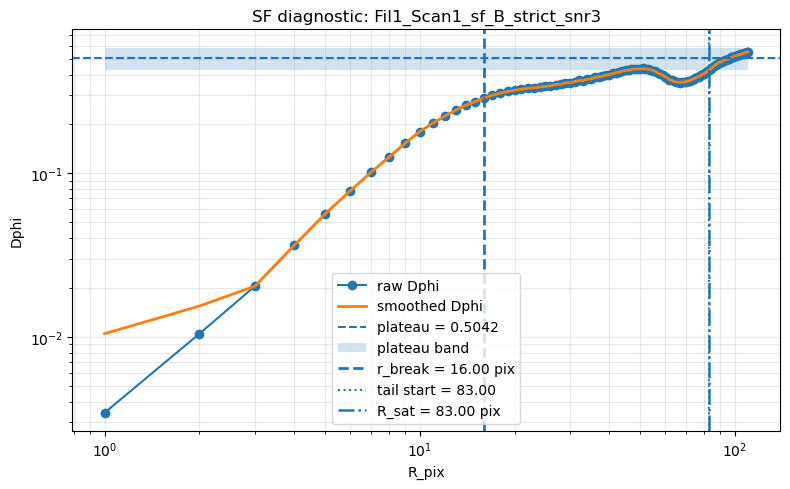

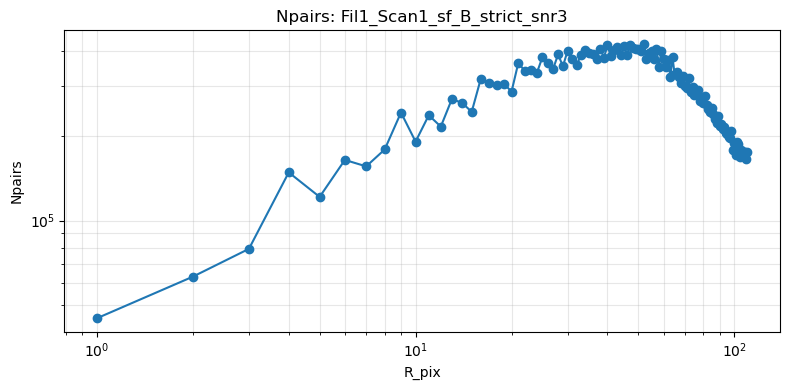

In [11]:
# =========================
# Run on one file
# =========================
if __name__ == "__main__":
    sf_path = r"report\fieldmaps_results\plots\Fil1_Scan1\Fil1_Scan1_sf_B_strict_snr3.csv"

    config = SFAnalysisConfig(
        r_col="R_pix",
        dphi_col="Dphi",
        npairs_col="Npairs",
        r_pc_col="R_pc",
        min_points=8,
        min_npairs=30,
        tail_fraction=0.25,
        smooth_window=5,
        rel_tol=0.08,
        sigma_tol=2.0,
        require_consecutive_tail_points=3,
    )

    df = load_sf_csv(sf_path)
    result, valid, extras = analyze_sf_table(df, config)

    print("\n=== SF ANALYSIS RESULT ===")
    for key, value in result.__dict__.items():
        print(f"{key}: {value}")

    break_info = extras.get("break_info", {})
    print("\n=== BREAK ESTIMATION ===")
    for key, value in break_info.items():
        print(f"{key}: {value}")

    break_info = extras.get("break_info", {})
    r_break_pix = break_info.get("r_break_pix", None)

    L_spine_pix = 87.15

    mach_result = estimate_mach_from_break_and_length(
        r_break_pix=r_break_pix,
        L_pix=L_spine_pix,
        object_name=result.object_name,
        mask_name=result.mask_name,
    )

    print("\n=== MACH ESTIMATION ===")
    for key, value in mach_result.__dict__.items():
        print(f"{key}: {value}")

    if len(valid) > 0:
        out_dir = Path(sf_path).parent

        # summary of plateau/saturation
        out_summary = pd.DataFrame([result.__dict__])
        out_csv = out_dir / (Path(sf_path).stem + "_analysis_summary.csv")
        out_summary.to_csv(out_csv, index=False)

        # summary of break
        out_break = pd.DataFrame([break_info])
        out_break_csv = out_dir / (Path(sf_path).stem + "_break_summary.csv")
        out_break.to_csv(out_break_csv, index=False)

        out_mach = pd.DataFrame([mach_result.__dict__])
        out_mach_csv = out_dir / (Path(sf_path).stem + "_mach_summary.csv")
        out_mach.to_csv(out_mach_csv, index=False)

        print(f"\nSaved summary to: {out_csv}")
        print(f"Saved break summary to: {out_break_csv}")
        print(f"Saved Mach summary to: {out_mach_csv}")

        plot_sf_diagnostic(
            valid,
            result,
            extras,
            config,
            title=f"SF diagnostic: {Path(sf_path).stem}",
        )
        plot_npairs(valid, config, title=f"Npairs: {Path(sf_path).stem}")
    else:
        print("\nNo valid points after filtering.")